<a href="https://colab.research.google.com/github/Theo-Prog10/classificacao-rochas-cnn/blob/main/mobilenet_rochas_ornamentais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
train_dir = "/content/drive/MyDrive/dataset/Ornamental Rocks dataset/processed_images_by_category_train_val_test/train"
val_dir = "/content/drive/MyDrive/dataset/Ornamental Rocks dataset/processed_images_by_category_train_val_test/val"
test_dir = "/content/drive/MyDrive/dataset/Ornamental Rocks dataset/processed_images_by_category_train_val_test/test"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10

In [ ]:
"Nessa etapa, foi aplicada a normalização dos pixels das imagens, convertendo seus valores originais, que variam de 0 a 255, "
"para o intervalo entre 0 e 1. Essa normalização foi aplicada aos conjuntos de treinamento, validação e teste."

train_datagen = ImageDataGenerator(
    rescale=1./255
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 1268 images belonging to 12 classes.


In [ ]:
val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 263 images belonging to 12 classes.


In [ ]:
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 263 images belonging to 12 classes.


In [ ]:
print(train_data.class_indices)

{'granite-blackswan': 0, 'granite-lucyinthesky': 1, 'granite-nevascawhite': 2, 'marble-dolomite-brancoparana': 3, 'marble-dolomite-calacata': 4, 'marble-shadow': 5, 'quartzite-biancosuperiore': 6, 'quartzite-oceanblue': 7, 'quartzite-patagonia': 8, 'quartzite-silvermoon': 9, 'quartzite-tajmahal': 10, 'quartzite-volupia': 11}


In [ ]:
images, labels = next(train_data)

print(images.shape)
print(labels.shape)

(32, 224, 224, 3)
(32, 12)


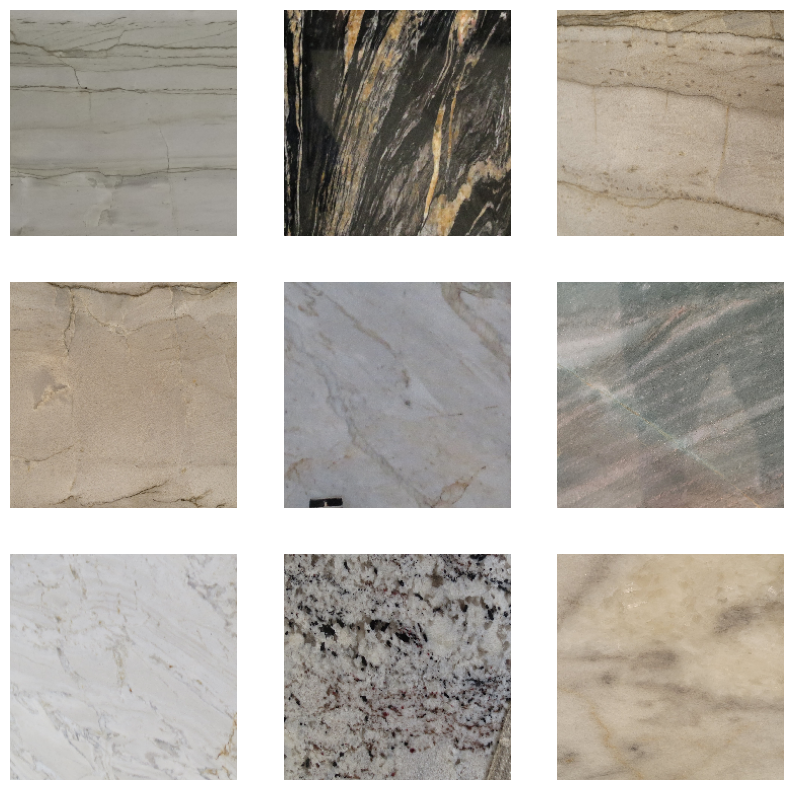

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

In [ ]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
"| Parâmetro          | O que significa                                       |"
"| ------------------ | ----------------------------------------------------- |"
"| input_shape        | tamanho da imagem de entrada                          |"
"| include_top=False  | remove a parte final da rede (classificador original) |"
"| weights='imagenet' | usa pesos já treinados                                |"


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
from tensorflow.keras import layers, models

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dense(12, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=x)

In [ ]:
"| Camada               | Função                                 |"
"| -------------------- | -------------------------------------- |"
"| GlobalAveragePooling | reduz dimensões                        |"
"| Dense(128)           | aprende padrões específicos das rochas |"
"| Dense(12)            | saída com 12 classes                   |"
"| softmax              | transforma em probabilidades           |"


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
"| Item      | Função                |"
"| --------- | --------------------- |"
"| optimizer | ajusta os pesos       |"
"| loss      | mede erro             |"
"| accuracy  | métrica de desempenho |"


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,423,500 (9.24 MB)

 Trainable params: 165,516 (646.55 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 509s 13s/step - accuracy: 0.7492 - loss: 0.8895 - val_accuracy: 0.8479 - val_loss: 0.4386
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.9472 - loss: 0.2117 - val_accuracy: 0.9202 - val_loss: 0.2701
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.9629 - loss: 0.1397 - val_accuracy: 0.9049 - val_loss: 0.2727
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.9795 - loss: 0.0903 - val_accuracy: 0.9430 - val_loss: 0.1839
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.9913 - loss: 0.0565 - val_accuracy: 0.9354 - val_loss: 0.1888
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.9929 - loss: 0.0424 - val_accuracy: 0.9354 - val_loss: 0.1748
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.9968 - loss: 0.0272 - val_accuracy: 0.9354 - val_loss: 0.1639
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.9968 - loss: 0.0243 - val_accuracy: 0.9430 - val_los

In [ ]:
model.save("/content/drive/MyDrive/tcc-rochas/mobilenetv2_rochas.h5")

In [ ]:
import pickle

with open("/content/drive/MyDrive/tcc-rochas/history.pkl", "wb") as f:
    pickle.dump(history.history, f)

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/tcc-rochas/mobilenetv2_rochas.h5")

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,423,502 (9.24 MB)

 Trainable params: 165,516 (646.55 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2 (12.00 B)

In [ ]:
test_loss, test_acc = model.evaluate(test_data)

print("Test accuracy:", test_acc)

9/9 ━━━━━━━━━━━━━━━━━━━━ 93s 11s/step - accuracy: 0.9582 - loss: 0.1474
Test accuracy: 0.9581748843193054


In [ ]:
model.save("mobilenet_rochas.h5")

In [ ]:
import numpy as np

predictions = model.predict(test_data)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_data.classes
class_labels = list(test_data.class_indices.keys())

9/9 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_classes, predicted_classes)

print(cm)

[[20  0  0  0  0  0  0  0  1  0  0  0]
 [ 0 24  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 24  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 16  0  0  1  0  0  1  0  0]
 [ 0  0  0  1 19  1  0  2  0  0  0  0]
 [ 0  0  0  0  0 21  0  0  1  0  0  0]
 [ 0  0  0  0  0  0 18  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 23  0  0  0  0]
 [ 0  0  0  0  1  0  0  0 22  0  0  1]
 [ 0  0  0  0  0  0  1  0  0 22  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 19  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 24]]


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(true_classes, predicted_classes, target_names=class_labels)

print(report)

                              precision    recall  f1-score   support

           granite-blackswan       1.00      0.95      0.98        21
        granite-lucyinthesky       1.00      1.00      1.00        24
        granite-nevascawhite       1.00      1.00      1.00        24
marble-dolomite-brancoparana       0.94      0.89      0.91        18
    marble-dolomite-calacata       0.95      0.83      0.88        23
               marble-shadow       0.95      0.95      0.95        22
   quartzite-biancosuperiore       0.90      1.00      0.95        18
         quartzite-oceanblue       0.92      1.00      0.96        23
         quartzite-patagonia       0.92      0.92      0.92        24
        quartzite-silvermoon       0.96      0.96      0.96        23
          quartzite-tajmahal       1.00      1.00      1.00        19
           quartzite-volupia       0.96      1.00      0.98        24

                    accuracy                           0.96       263
                  

In [ ]:
import pandas as pd

cm_df = pd.DataFrame(cm, index=class_labels, columns=class_labels)
cm_df.to_csv("confusion_matrix.csv")

In [ ]:
# salvar report
with open("classification_report.txt", "w") as f:
    f.write(report)

# salvar matriz
cm_df.to_csv("confusion_matrix.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
cm_df.to_csv("/content/drive/MyDrive/confusion_matrix.csv")

with open("/content/drive/MyDrive/classification_report.txt", "w") as f:
    f.write(report)

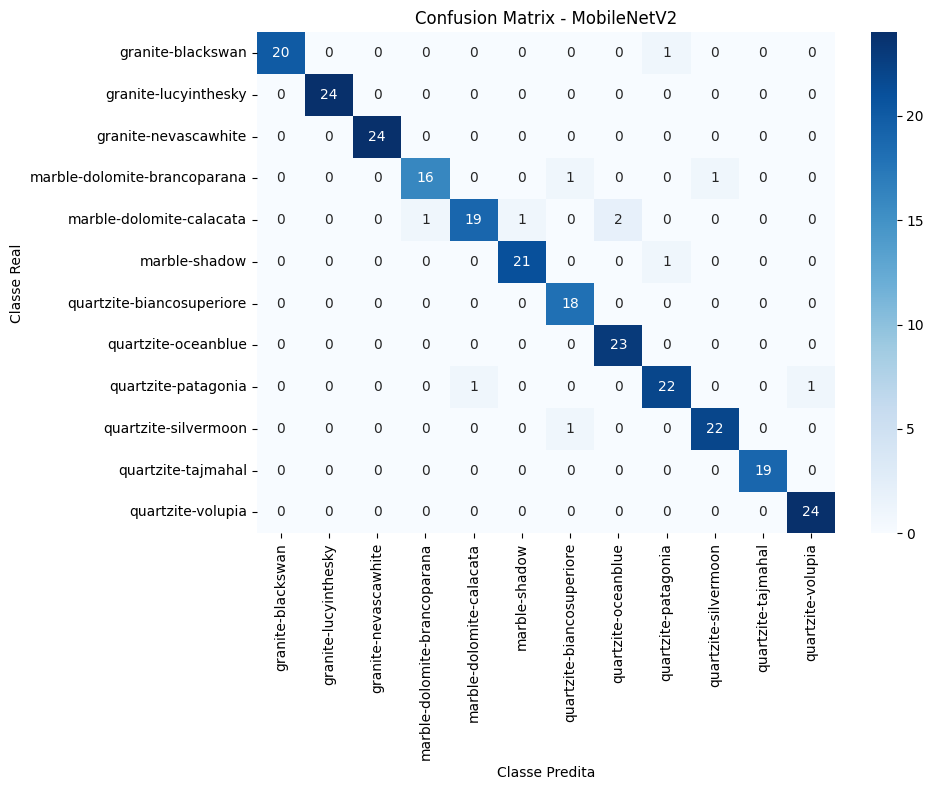

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# transformar matriz em DataFrame
cm_df = pd.DataFrame(cm, index=class_labels, columns=class_labels)

plt.figure(figsize=(10,8))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - MobileNetV2")
plt.ylabel("Classe Real")
plt.xlabel("Classe Predita")

plt.tight_layout()

In [ ]:
save_path = "/content/drive/MyDrive/tcc-rochas/confusion_matrix.png"

plt.savefig(save_path, dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

x = base_model.output
x = GlobalAveragePooling2D()(x)

predictions = Dense(12, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=predictions)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 745s 17s/step - accuracy: 0.8588 - loss: 0.4860 - val_accuracy: 0.2091 - val_loss: 11.5319
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 308s 8s/step - accuracy: 0.9322 - loss: 0.2685 - val_accuracy: 0.2510 - val_loss: 13.5478
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 330s 8s/step - accuracy: 0.9385 - loss: 0.2344 - val_accuracy: 0.2357 - val_loss: 21.7957
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 303s 8s/step - accuracy: 0.9495 - loss: 0.1924 - val_accuracy: 0.4068 - val_loss: 9.2942
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 325s 8s/step - accuracy: 0.9621 - loss: 0.1449 - val_accuracy: 0.1787 - val_loss: 28.3389
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 303s 8s/step - accuracy: 0.9416 - loss: 0.2180 - val_accuracy: 0.0722 - val_loss: 22.3230
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 327s 8s/step - accuracy: 0.9614 - loss: 0.1382 - val_accuracy: 0.2129 - val_loss: 15.5687
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 300s 7s/step - accuracy: 0.9724 - loss: 0.1025 - val_accuracy: 0.2

In [ ]:
import pandas as pd

history_df = pd.DataFrame(history.history)

history_df.to_csv(
    "/content/drive/MyDrive/tcc-rochas/training_history.csv",
    index=False
)

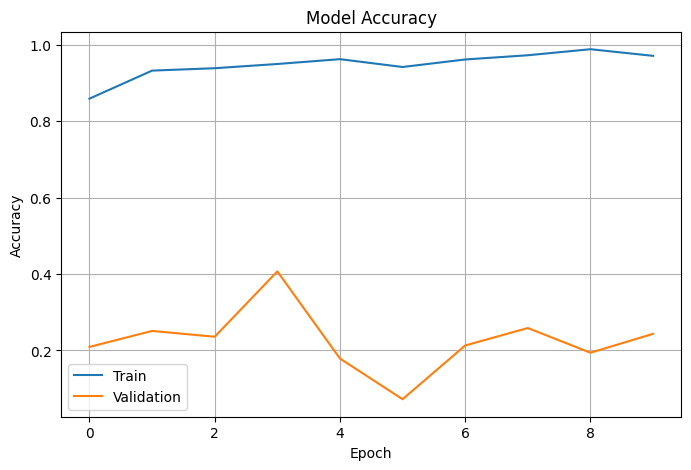

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])
plt.grid()

plt.savefig("/content/drive/MyDrive/tcc-rochas/training_accuracy.png", dpi=300)

plt.show()

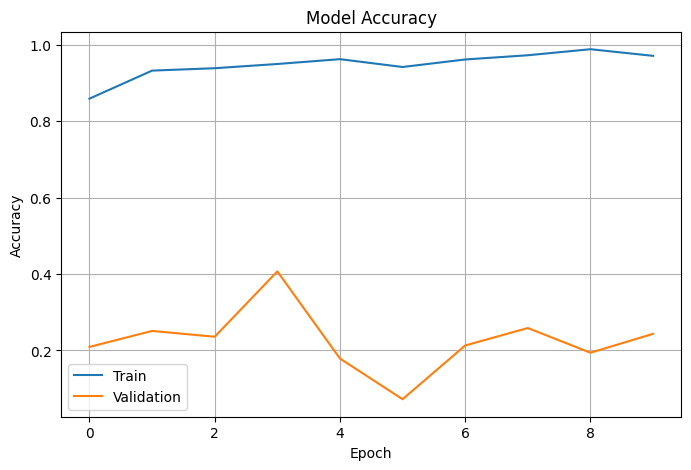

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])
plt.grid()

plt.savefig("/content/drive/MyDrive/tcc-rochas/training_accuracy.png", dpi=300)

plt.show()

In [ ]:
model.save("/content/drive/MyDrive/tcc-rochas/modelo_mobilenet_rochas.h5")

In [ ]:
import json

with open("/content/drive/MyDrive/tcc-rochas/classes.json", "w") as f:
    json.dump(train_data.class_indices, f)

In [ ]:
import os

exp2_path = "/content/drive/MyDrive/tcc-rochas/experimento_02_data_augmentation"

os.makedirs(exp2_path, exist_ok=True)

print("Pasta criada:", exp2_path)

Pasta criada: /content/drive/MyDrive/tcc-rochas/experimento_02_data_augmentation


In [ ]:
dataset_path = "/content/drive/MyDrive/dataset/Ornamental Rocks dataset/processed_images_by_category_train_val_test"

train_dir = dataset_path + "/train"
val_dir = dataset_path + "/val"
test_dir = dataset_path + "/test"

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

In [ ]:
val_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1268 images belonging to 12 classes.
Found 263 images belonging to 12 classes.
Found 263 images belonging to 12 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
output = layers.Dense(12, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
EPOCHS = 10

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 669s 17s/step - accuracy: 0.7232 - loss: 0.8885 - val_accuracy: 0.8707 - val_loss: 0.4594
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.9069 - loss: 0.2962 - val_accuracy: 0.8707 - val_loss: 0.3629
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.9306 - loss: 0.2085 - val_accuracy: 0.8973 - val_loss: 0.3610
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.9543 - loss: 0.1492 - val_accuracy: 0.9011 - val_loss: 0.3612
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.9716 - loss: 0.1193 - val_accuracy: 0.8745 - val_loss: 0.3424
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.9614 - loss: 0.1149 - val_accuracy: 0.9087 - val_loss: 0.3378
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 104s 3s/step - accuracy: 0.9716 - loss: 0.1074 - val_accuracy: 0.9011 - val_loss: 0.2810
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.9740 - loss: 0.0901 - val_accuracy: 0.9087 - val_

In [ ]:
model.save(exp2_path + "/mobilenet_exp2_data_augmentation.keras")

In [ ]:
test_loss, test_acc = model.evaluate(test_data)

print("Test accuracy:", test_acc)

9/9 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9316 - loss: 0.1816
Test accuracy: 0.9315589070320129


In [ ]:
with open(exp2_path + "/test_accuracy.txt", "w") as f:
    f.write(str(test_acc))

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

predictions = model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)

report = classification_report(test_data.classes, y_pred)

print(report)

9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step
              precision    recall  f1-score   support

           0       0.91      0.95      0.93        21
           1       1.00      0.83      0.91        24
           2       1.00      1.00      1.00        24
           3       0.94      0.89      0.91        18
           4       0.88      0.96      0.92        23
           5       0.96      1.00      0.98        22
           6       0.94      0.83      0.88        18
           7       0.96      1.00      0.98        23
           8       0.88      0.92      0.90        24
           9       0.85      0.96      0.90        23
          10       1.00      0.89      0.94        19
          11       0.92      0.92      0.92        24

    accuracy                           0.93       263
   macro avg       0.94      0.93      0.93       263
weighted avg       0.93      0.93      0.93       263



In [ ]:
with open(exp2_path + "/classification_report.txt", "w") as f:
    f.write(report)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_data.classes, y_pred)

In [ ]:
import pandas as pd

class_labels = list(train_data.class_indices.keys())

cm_df = pd.DataFrame(cm, index=class_labels, columns=class_labels)

cm_df.to_csv(exp2_path + "/confusion_matrix.csv")

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy - Experimento 2')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.savefig(exp2_path + "/training_accuracy.png", dpi=300)
plt.close()

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss - Experimento 2')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.savefig(exp2_path + "/training_loss.png", dpi=300)
plt.close()

In [ ]:
import pickle

with open(exp2_path + "/history.pkl", "wb") as f:
    pickle.dump(history.history, f)

In [ ]:
with open(exp2_path + "/test_accuracy.txt", "r") as f:
    print("Test Accuracy Experimento 2:", f.read())

Test Accuracy Experimento 2: 0.9315589070320129


In [ ]:
import pandas as pd

cm = pd.read_csv(exp2_path + "/confusion_matrix.csv", index_col=0)

cm

,granite-blackswan,granite-lucyinthesky,granite-nevascawhite,marble-dolomite-brancoparana,marble-dolomite-calacata,marble-shadow,quartzite-biancosuperiore,quartzite-oceanblue,quartzite-patagonia,quartzite-silvermoon,quartzite-tajmahal,quartzite-volupia
granite-blackswan,20,0,0,0,0,0,0,0,1,0,0,0
granite-lucyinthesky,2,20,0,0,0,1,0,0,0,0,0,1
granite-nevascawhite,0,0,24,0,0,0,0,0,0,0,0,0
marble-dolomite-brancoparana,0,0,0,16,0,0,1,0,0,1,0,0
marble-dolomite-calacata,0,0,0,1,22,0,0,0,0,0,0,0
marble-shadow,0,0,0,0,0,22,0,0,0,0,0,0
quartzite-biancosuperiore,0,0,0,0,0,0,15,0,0,3,0,0
quartzite-oceanblue,0,0,0,0,0,0,0,23,0,0,0,0
quartzite-patagonia,0,0,0,0,2,0,0,0,22,0,0,0
quartzite-silvermoon,0,0,0,0,0,0,0,1,0,22,0,0


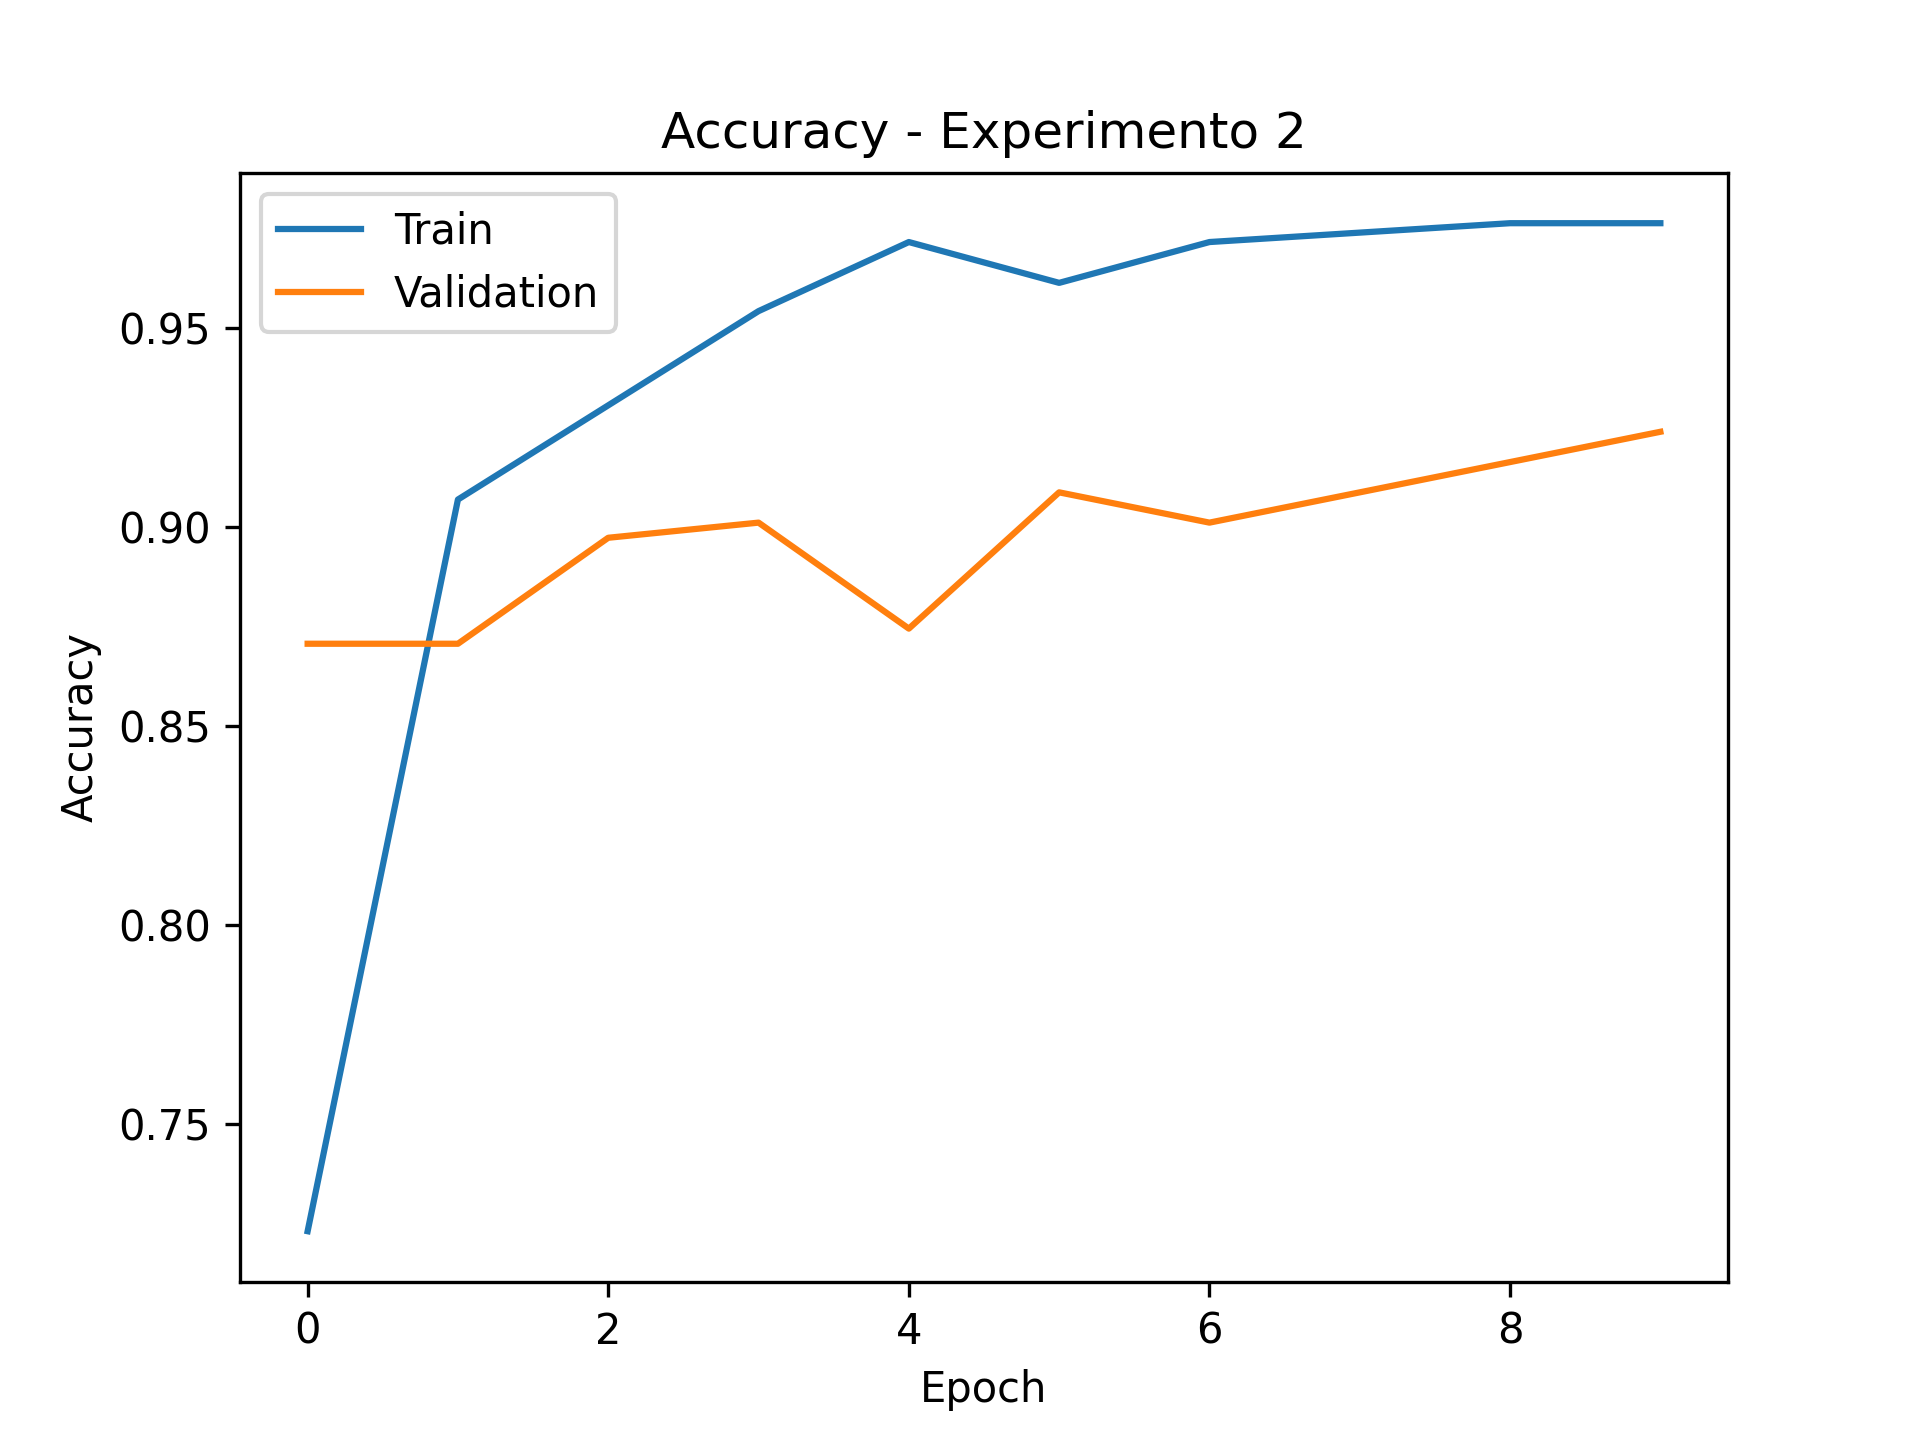

In [ ]:
from IPython.display import Image

Image(exp2_path + "/training_accuracy.png")

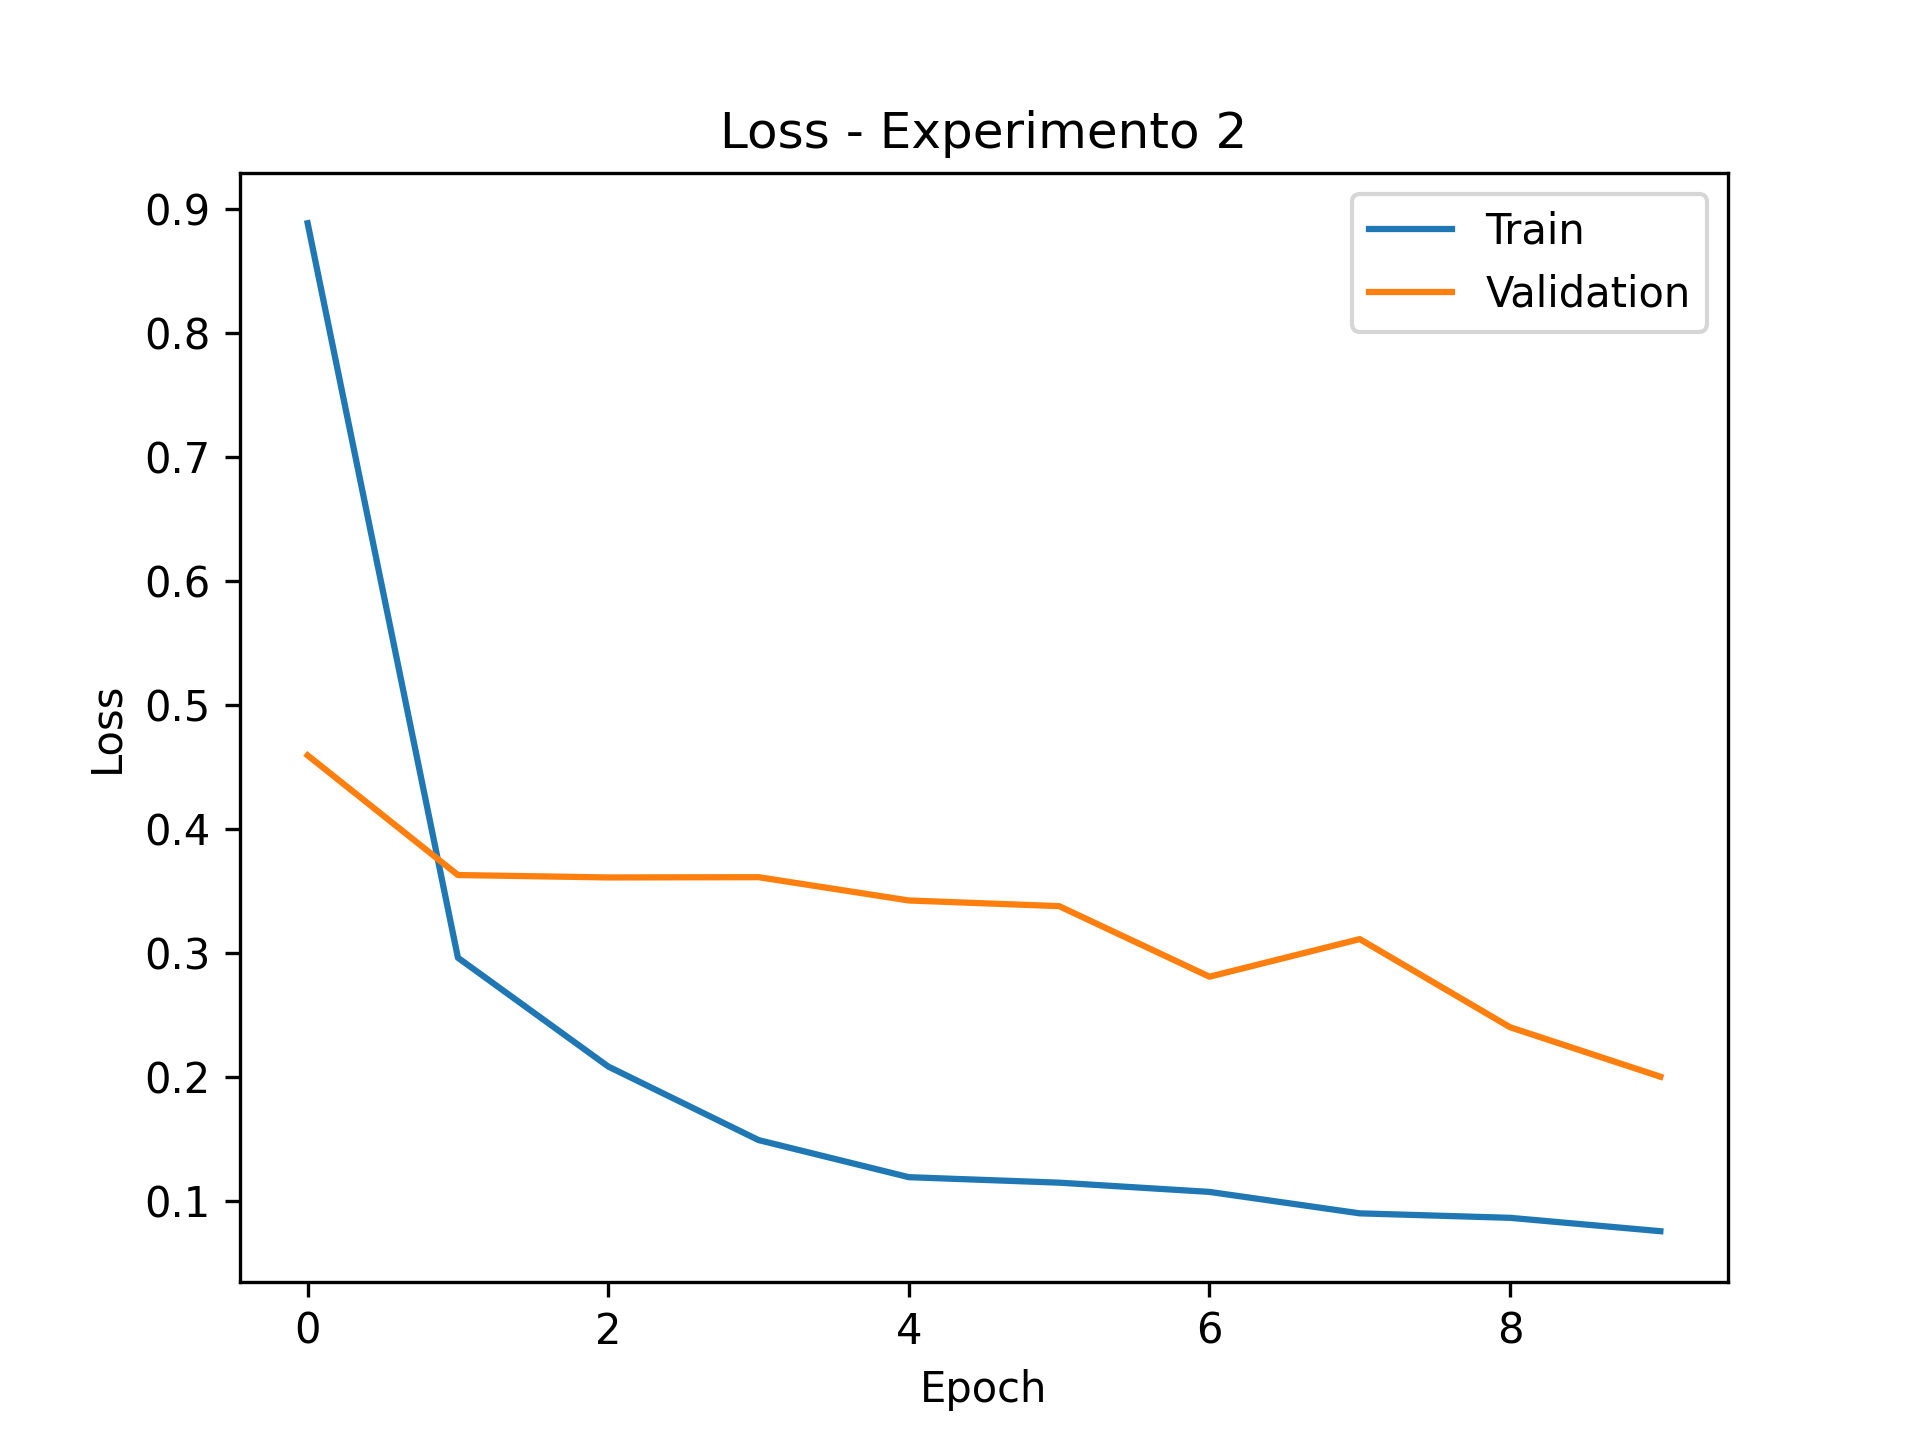

In [ ]:
Image(exp2_path + "/training_loss.png")

In [ ]:
with open("/content/drive/MyDrive/tcc-rochas/resultados_experimentos.txt", "a") as f:
    f.write("Experimento 2 - MobileNetV2 + Data Augmentation\n")
    f.write("Accuracy: " + str(test_acc) + "\n\n")

In [ ]:
import os

exp3_path = "/content/drive/MyDrive/tcc-rochas/experimento_03_mais_epocas"
os.makedirs(exp3_path, exist_ok=True)

print("Pasta criada:", exp3_path)

Pasta criada: /content/drive/MyDrive/tcc-rochas/experimento_03_mais_epocas


In [ ]:
dataset_path = "/content/drive/MyDrive/tcc-rochas/dataset/Ornamental Rocks dataset/processed_images_by_category_train_val_test"

train_dir = dataset_path + "/train"
val_dir = dataset_path + "/val"
test_dir = dataset_path + "/test"

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model

from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1268 images belonging to 12 classes.
Found 263 images belonging to 12 classes.
Found 263 images belonging to 12 classes.


In [ ]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
output = layers.Dense(12, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 427s 11s/step - accuracy: 0.7642 - loss: 0.8364 - val_accuracy: 0.8973 - val_loss: 0.3156
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.9424 - loss: 0.2037 - val_accuracy: 0.9202 - val_loss: 0.2519
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.9756 - loss: 0.1096 - val_accuracy: 0.9316 - val_loss: 0.2161
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.9858 - loss: 0.0739 - val_accuracy: 0.9354 - val_loss: 0.1937
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.9874 - loss: 0.0548 - val_accuracy: 0.9506 - val_loss: 0.1499
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.9953 - loss: 0.0374 - val_accuracy: 0.9392 - val_loss: 0.1568
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.9968 - loss: 0.0300 - val_accuracy: 0.9506 - val_loss: 0.1350
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.9968 - loss: 0.0234 - val_accuracy: 0.9354 - val_los

In [ ]:
model.save(exp3_path + "/mobilenet_exp3_mais_epocas.keras")

In [ ]:
history_df = pd.DataFrame(history.history)
history_df.to_csv(exp3_path + "/training_history.csv", index=False)

with open(exp3_path + "/history.pkl", "wb") as f:
    pickle.dump(history.history, f)

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy - Experimento 3')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.grid()

plt.savefig(exp3_path + "/training_accuracy.png", dpi=300)
plt.close()

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss - Experimento 3')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.grid()

plt.savefig(exp3_path + "/training_loss.png", dpi=300)
plt.close()

In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print("Test accuracy:", test_acc)

9/9 ━━━━━━━━━━━━━━━━━━━━ 63s 8s/step - accuracy: 0.9696 - loss: 0.1099
Test accuracy: 0.9695817232131958


In [ ]:
with open(exp3_path + "/test_accuracy.txt", "w") as f:
    f.write(str(test_acc))

with open(exp3_path + "/test_loss.txt", "w") as f:
    f.write(str(test_loss))

In [ ]:
predictions = model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)

report = classification_report(test_data.classes, y_pred, target_names=list(test_data.class_indices.keys()))
print(report)

9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step
                              precision    recall  f1-score   support

           granite-blackswan       1.00      0.95      0.98        21
        granite-lucyinthesky       1.00      1.00      1.00        24
        granite-nevascawhite       1.00      1.00      1.00        24
marble-dolomite-brancoparana       1.00      0.89      0.94        18
    marble-dolomite-calacata       0.95      0.87      0.91        23
               marble-shadow       0.92      1.00      0.96        22
   quartzite-biancosuperiore       0.90      1.00      0.95        18
         quartzite-oceanblue       1.00      1.00      1.00        23
         quartzite-patagonia       0.92      0.96      0.94        24
        quartzite-silvermoon       0.96      0.96      0.96        23
          quartzite-tajmahal       1.00      1.00      1.00        19
           quartzite-volupia       1.00      1.00      1.00        24

                    accuracy                       

In [ ]:
with open(exp3_path + "/classification_report.txt", "w") as f:
    f.write(report)

In [ ]:
cm = confusion_matrix(test_data.classes, y_pred)
class_labels = list(test_data.class_indices.keys())

cm_df = pd.DataFrame(cm, index=class_labels, columns=class_labels)
cm_df.to_csv(exp3_path + "/confusion_matrix.csv")

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Experimento 3")
plt.ylabel("Classe Real")
plt.xlabel("Classe Predita")
plt.tight_layout()

plt.savefig(exp3_path + "/confusion_matrix.png", dpi=300)
plt.close()

In [ ]:
with open(exp3_path + "/resumo_experimento.txt", "w") as f:
    f.write("Experimento 3 - MobileNetV2 com mais épocas\n")
    f.write(f"IMG_SIZE: {IMG_SIZE}\n")
    f.write(f"BATCH_SIZE: {BATCH_SIZE}\n")
    f.write(f"EPOCHS: {EPOCHS}\n")
    f.write("Data augmentation: nao\n")
    f.write(f"Test accuracy: {test_acc}\n")
    f.write(f"Test loss: {test_loss}\n")